In [1]:
import torch
from torch.nn.functional import grid_sample
from math import ceil
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.special import roots_legendre
from tqdm.auto import tqdm
from pathlib import Path
import numpy as np

test = False
index = 6
shft = 0

# Definitions

In [13]:
def B_spline(n, x):
    """
    Compute degree `n` B-splines.

    In this way, the sum of all cakewavelets in the Fourier domain is
    identically equal to 1 (within the disk M), while each cakewavelet varies
    smoothly in the angular direction in the Fourier domain. See Section 4.6
    in Duits "Perceptual Organization in Image Analysis" (2005).

    For degree `n` <= 3, we use explicit formulae. For higher orders, a
    recursive algorithm is used.
    """
    # if not isinstance(n, int) or n < 0:
    #     raise ValueError("n must be a positive integer")
    match n:
        case 0:
            b = 1 * (-1/2 <= x) * (x < 1/2)
        case 1:
            b = (
                (1. + x) * (-1. <= x) * (x < 0.) +
                (1. - x) * (0. <= x)  * (x < 1.)
            )
        case 2:
            b = (
                ((3/2 + x)**2)/2 * (-3/2 <= x) * (x < -1/2) +
                (3/4 - x**2)     * (-1/2 <= x) * (x < 1/2) +
                ((3/2 - x)**2)/2 * (1/2 <= x)  * (x < 3/2)
            )
        case 3:
            b = (
                ((2. + x)**3)/6         * (-2. <= x) * (x < -1.) + 
                (2/3 - x**2 - (x**3)/2) * (-1. <= x) * (x < -0.) + 
                (2/3 - x**2 + (x**3)/2) * (0. <= x)  * (x < 1.)  + 
                ((2. - x)**3)/6         * (1. <= x)  * (x < 2.)
            )
        case _:
            raise ValueError("n > 3 not implemented")
    return b

def dB_spline(n, x):
    """
    Compute the derivative with respect to x of the degree `n` B-spline.

    """
    match n:
        case 0:
            b_prime = 0. * (-1/2 <= x) * (x < 1/2)
            
        case 1:
            b_prime = (
                1. * (-1. <= x) * (x < 0.) +
               -1. * (0. <= x)  * (x < 1.)
            )
            
        case 2:
            b_prime = (
                (3/2 + x)  * (-3/2 <= x) * (x < -1/2) +
                (-2. * x)  * (-1/2 <= x) * (x < 1/2) +
                (-3/2 + x) * (1/2 <= x)  * (x < 3/2)
            )
            
        case 3:
            b_prime = (
                ((2. + x)**2)/2         * (-2. <= x) * (x < -1.) +
                (-2.*x - 1.5*(x**2))    * (-1. <= x) * (x < 0.) +
                (-2.*x + 1.5*(x**2))    * (0. <= x)  * (x < 1.) +
                (-((2. - x)**2)/2)      * (1. <= x)  * (x < 2.)
            )
            
        case _:
            raise ValueError("n > 3 not implemented")
            
    return b_prime

def modulo(x, d, offset=0.):
    return x - (x - offset)//d * d

def fit_B_spline(cp, t):
    device = cp.device
    
    #control points (cp) has shape θ,y,x
    N = cp.shape[0]

    #parameterization
    t_i = torch.linspace(0, 1, steps = t, dtype=torch.float32, device=device)
    N_i = torch.linspace(0, 1, steps= N+1, dtype=torch.float32, device=device)
    t_is = modulo(t_i[None, : ] - N_i[:-1, None], 1, offset=-1/2)

    #Make Bspline basis
    Bsplines = B_spline(3, t_is * N)      
    dBsplines = dB_spline(3, t_is * N) * N
    
    #Bspline curve
    theta_cp = cp[:, 0]
    cp_cos = torch.cos(theta_cp)
    cp_sin = torch.sin(theta_cp)
    cos_curve = (cp_cos[:, None] * Bsplines).sum(0)    
    sin_curve = (cp_sin[:, None] * Bsplines).sum(0)   
    θ = torch.remainder(torch.atan2(sin_curve, cos_curve), 2 * torch.pi)

    y = (cp[:, 1][:, None] * Bsplines).sum(0)
    x = (cp[:, 2][:, None] * Bsplines).sum(0)
    curve = torch.stack([θ, y, x], dim=1)
    

    #Derivative of bspline curve
    dcos = (cp_cos[:, None] * dBsplines).sum(0)
    dsin = (cp_sin[:, None] * dBsplines).sum(0)
    denom = cos_curve**2 + sin_curve**2 + 1e-8  # avoid division issues
    dθ = (cos_curve * dsin - sin_curve * dcos) / denom

    dy = (cp[:, 1][:, None] * dBsplines).sum(0)
    dx = (cp[:, 2][:, None] * dBsplines).sum(0)

    dθyx_curve = torch.stack([dθ, dy, dx], dim=1)

    #derivative in Left-invariant frame
    θ = curve[:, 0]
    cos = torch.cos(θ)
    sin = torch.sin(θ)

    A1 = cos * dx + sin * dy
    A2 = -sin * dx + cos * dy 
    A3 = dθ
        
    LI_curve = torch.stack([A3, A2, A1], dim=1)

    return curve, LI_curve, dθyx_curve 
   
def plus_control(g_11, g_22, g_33, cost, curve, dcurve):
    A1 = dcurve[:, 2]
    A2 = dcurve[:, 1]
    A3 = dcurve[:, 0]
    
    # cost function blurred       
    finsler_metric = cost_function_interpolation(cost, curve) *  (g_11 * A1**2 + g_22 * A2**2 + g_33 * A3**2).sqrt()  #+ 10**6 * torch.clamp_max(A1, 0)**2
    return finsler_metric

def cost_function_interpolation(cost, curve):
    device = curve.device
    _ , dim_y, dim_x = cost.shape
    scale_center = torch.tensor([torch.pi, dim_y/2, dim_x/2], device=device)[None]
    scale_div = torch.tensor([torch.pi, dim_y/2, dim_x/2], device=device)[None]
    curve_rescale = (curve - scale_center) / scale_div    
    grid = curve_rescale.flip(dims=[1])[None, None, None]   
    return grid_sample(cost[None, None], grid, padding_mode="border", align_corners=True)[0, 0, 0, 0]

def length_functional(g_11, g_22, g_33, cost, curve, dcurve):

    finsler_metric = plus_control(g_11, g_22, g_33, cost, curve, dcurve) 
    return torch.mean(finsler_metric)

def max_pair(cost, curve, sigma):
    #use interplotion the find the cost over the curve
    cost_curve = cost_function_interpolation(cost,curve)  
    N = len(curve)  
    
    #smooth the cost over the curve    
    sigma_current = sigma

    while True:
        radius = ceil(3.0 * sigma_current)

        if radius < 1:
            # fallback
            cost_curve_smooth = cost_curve
            break

        if radius < N:
            x = torch.arange(-radius, radius + 1, device=cost_curve.device)
            kernel = torch.exp(-x**2 / (2 * sigma_current**2))
            kernel = kernel / kernel.sum()
            kernel = kernel.view(1, 1, -1)

            cost_padded = F.pad(cost_curve[None, None], (radius, radius), mode='circular')

            cost_curve_smooth = F.conv1d(cost_padded, kernel)[0, 0]
            break

        sigma_current /= 2
    
    #find local minima
    dcost = cost_curve_smooth - torch.roll(cost_curve_smooth, -1)  #backward derivative: cost[i] - cost[i - 1]
    minima = (dcost > 0) & (torch.roll(dcost, -1) < 0) #d_cost[i-1] < 0, decreasing and d_cost[i] > 0, increasing
    minima_idx = torch.where(minima)[0]
        
    # Compute standard deviation of the cost curve
    cost_std = torch.std(cost_curve)
    cost_mean = torch.mean(cost_curve)

    # Keep only minima whose cost is <= std (or remove those > std)
    valid_mask = cost_curve_smooth[minima_idx] <= cost_mean  # + 1 * cost_std 
    minima_idx = minima_idx[valid_mask]
    
    threshold = cost_mean + 2 * cost_std

    pairs = []

    for i in range(len(minima_idx)):
        
        a = minima_idx[i-1].item()
        b = minima_idx[i].item()

        # handle circular segment
        if a < b:
            segment = cost_curve_smooth[a:b]
        else:
            segment = torch.cat((cost_curve_smooth[a:], cost_curve_smooth[:b]))

        # check condition
        if torch.max(segment) > threshold:
            if a != b:
                pairs.append([a, b])

    # convert to tensor
    if len(pairs) > 0:
        pairs = torch.tensor(pairs, device=curve.device)
        points = curve[pairs]   # shape: (#pairs, 2, dim)
    else:
        print("No valid pairs found")
        points = torch.empty(0, 2, curve.shape[1], device=curve.device)
        

    return pairs, points


def grouped_costfunction(i, K, masks, costs):
    
    if masks[i].shape == costs[i].shape:
        grouped_cost = torch.where(
                masks[i] == K,
                costs[i],
                torch.ones_like(masks[i])
            )
    else:
        print("bad! Shape of mask is not the same as shape of the cost function")

    return grouped_cost



# Import initial guess boundary

In [3]:
root_dir = "C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/"
if not test:
    lifted_contours_blobs = torch.load(root_dir + f"Files synthetic/lifted_contours_blobs.pt", map_location='cuda') #_shift_{shft}
    lifted_contours = torch.load(root_dir + f"Files synthetic/lifted_contours.pt", map_location='cuda')

    mask_cost_functions = torch.load(root_dir + f"Files synthetic/mask_cost_functions.pt", map_location="cuda")
    costfunctions = torch.load(root_dir + f"Files synthetic/costfunctions_nobin.pt", map_location="cuda") #nobin
else:
    lifted_contours_blobs = torch.load(f"lifted_contours_blobs_test_{index}.pt", map_location='cuda')
    lifted_contours = torch.load(f"lifted_contours_test_{index}.pt", map_location='cuda')

    mask_cost_functions = torch.load(root_dir + f"mask_cost_functions_test_{index}.pt", map_location="cuda")
    costfunctions = torch.load(root_dir + f"costfunctions_test_{index}.pt", map_location="cuda")

lifted_contours_combined = [
    lines + blobs 
    for lines, blobs in zip(lifted_contours, lifted_contours_blobs)
]


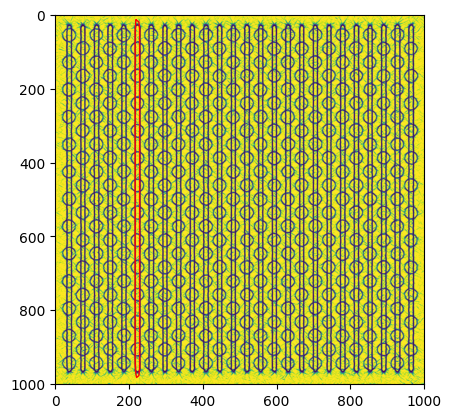

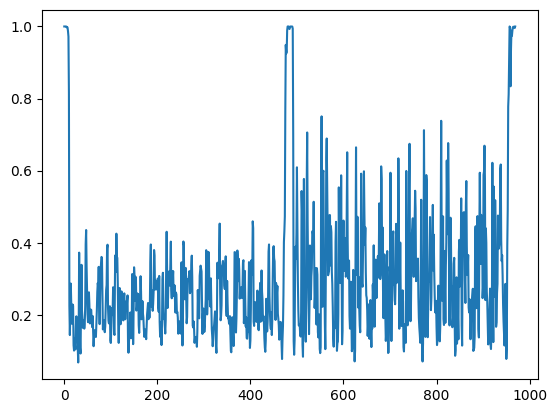

In [4]:
per = 0.1
K = 3
N = lifted_contours_combined[0][K].shape[0]
num_elements = int(N * per)
indices = torch.linspace(0, N - 1, steps=num_elements, dtype=torch.long, device=lifted_contours[0][0].device)

coor = lifted_contours_combined[0][K][indices]

plt.imshow((torch.min(costfunctions[0], dim=0).values).cpu())
plt.plot((coor[:,2]).cpu(), (coor[:,1]).cpu(), color='red', linewidth=1)
plt.axis('on')
plt.show()

t = 5
curve, LI_curve, dθyx_curve = fit_B_spline( coor , 5 * coor.shape[0]) 

plt.plot(cost_function_interpolation(costfunctions[0],curve).cpu())

# Approximation geodesic with B spline

Start from an initial guess and iteratively refine it to approximate the geodesic

In [5]:
per = 1.
approx_curves = []
cps = []

for i in range(len(lifted_contours_combined)):

    curves_per_image = []
    cp_per_image = []

    for K in tqdm(range(len(lifted_contours_combined[i]))):

        N = lifted_contours_combined[i][K].shape[0]
        num_elements = int(N * per)
        indices = torch.linspace(0, N - 1, steps=num_elements, dtype=torch.long, device=lifted_contours_combined[i][K].device)
        coor = lifted_contours_combined[i][K][indices]

        coor = coor.detach().clone().requires_grad_(True)
        parameters = [coor]
        optimizer = torch.optim.Adam(parameters, lr=0.5) #0.01
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=1.)

        losses = []
        num_epochs = 200 
        t = 5

        for epoch in range(num_epochs):
            epoch_loss = 0    
            optimizer.zero_grad() # set x.grad = 0 for all relevant tensors x 
            
            grouped_cost = grouped_costfunction(i, K, mask_cost_functions,costfunctions)
            curve, LI_curve, dθyx_curve = fit_B_spline(coor, t*coor.shape[0])
            
            loss = length_functional(1.56, 1e6, 1., grouped_cost, curve, LI_curve)  #0.02, 0.5 #1.12, 2. #xi = sqrt(g11/g33) --> g33=1 and g11= xi^2 = (1.25)^2 = 1.56 . ( (2*3.14)/10)^2
            loss.backward() # x.grad += (pd loss)/(pd x) for all relevant tensors x
            
            optimizer.step()    
            epoch_loss += loss.item()          
            scheduler.step()
            
            # average loss 
            avg_loss = epoch_loss 
            losses.append(avg_loss)

        curves_per_image.append(curve)
        cp_per_image.append(coor)

    approx_curves.append(curves_per_image)
    cps.append(cp_per_image)

# if test == False:
#     torch.save(approx_curves, f"approx_curves.pt")
#     torch.save(cps, f"controlpoints.pt")
# else:
#     torch.save(approx_curves, f"approx_curves_test_{index}.pt")
#     torch.save(cps, f"controlpoints_test.pt")



  0%|          | 0/392 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [6]:
if test == False:
    approx_curves = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files synthetic/approx_curves.pt")
else:
    approx_curves = torch.load(f"C:/Users/levis/OneDrive - ASML/Documents/Paper 2- Training Cost Function/learning parameters/Files experimental/approx_curves_test_{index}.pt")


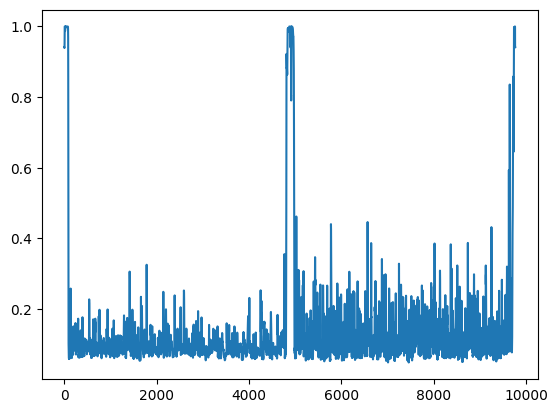

In [10]:
i = 0
K = 2

with torch.no_grad():
    grouped_cost = grouped_costfunction(i,K, mask_cost_functions,costfunctions)
    plt.plot(cost_function_interpolation(grouped_cost,approx_curves[i][K]).cpu())





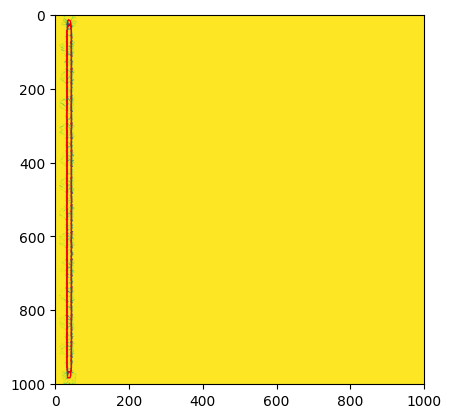

In [11]:
plt.imshow((torch.min(grouped_cost, dim=0).values).cpu())
plt.plot((approx_curves[i][K][:,2]).detach().cpu().numpy(), (approx_curves[i][K][:,1]).detach().cpu().numpy(), color='red', linewidth=1)
plt.axis('on')
plt.show()

# Identify points where the cost function is still high

In [14]:
sinksandsources = []
with torch.no_grad():
    for i,per_image in enumerate(approx_curves):
        sinksandsources_per_image = []

        for K,curve in tqdm(enumerate(per_image)):
            points = max_pair(grouped_costfunction(i,K, mask_cost_functions,costfunctions), curve, 1/1000 * len(curve))
            sinksandsources_per_image.append(points)

        sinksandsources.append(sinksandsources_per_image)

if test == False:
    torch.save(sinksandsources, f"sinksandsources.pt")
else:
    torch.save(sinksandsources, f"sinksandsources_test_{index}.pt")



0it [00:00, ?it/s]

No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found


0it [00:00, ?it/s]

No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found


0it [00:00, ?it/s]

No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found
No valid pairs found


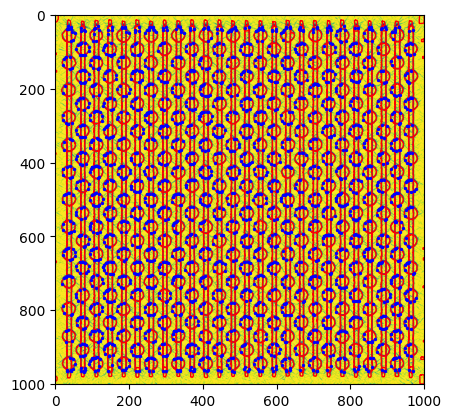

In [15]:
i=0
plt.imshow((torch.min(costfunctions[i], dim=0).values).cpu())

for K in range(len(approx_curves[i])):
    plt.plot((approx_curves[i][K][:,2]).detach().cpu().numpy(), (approx_curves[i][K][:,1]).detach().cpu().numpy(), color='red', linewidth=1)
    plt.scatter(sinksandsources[i][K][1][:,:,2].detach().cpu().numpy(), sinksandsources[i][K][1][:,:,1].detach().cpu().numpy(), color='blue', s=2, zorder=10)
plt.axis('on')
plt.show()